# Pré-processamento das Imagens — Dataset CNPEM

Este notebook implementa a etapa de **pré-processamento das imagens** de placas
de Petri do dataset CNPEM, preparando os dados para o pipeline de detecção e
contagem de colônias do notebook seguinte (`2_pipeline_contagem_colonias_cnpem.ipynb`).

A proposta desta etapa é padronizar a entrada visual e reduzir variações
irrelevantes (fundo externo, iluminação e escala), para que a segmentação das
colônias ocorra de forma mais estável e reprodutível.

A estratégia adotada combina:
- padronização de tamanho da imagem;
- conversão para uma representação em tons de cinza via PCA (a partir dos canais RGB);
- detecção automática da placa com `HoughCircles`;
- aplicação de máscara circular para manter apenas a região útil da placa.

O resultado final deste notebook é um conjunto de imagens pré-processadas salvo
em `data/interim`, que será consumido diretamente na etapa de contagem.

## Estrutura deste notebook

1. Configuração do ambiente (caminhos reprodutíveis)
2. Função principal de pré-processamento
3. Execução em uma única imagem de exemplo
4. Processamento em lote e salvamento das imagens pré-processadas
5. Verificação dos arquivos gerados


## 1. Configuração do ambiente

Definição centralizada dos caminhos utilizados ao longo do notebook, de forma
a manter a execução reprodutível em qualquer ambiente (não exclusivamente no
Google Colab).

- `DATASET_ROOT`: diretório de trabalho atual do notebook.
- `IMAGES_DIR`: pasta com as imagens originais (`../data/raw`).
- `CROP_CIRCLES_DIR`: pasta onde serão salvas as imagens pré-processadas (`../data/interim`).

Essa organização evita caminhos fixos de máquina e facilita a execução do
pipeline em diferentes sistemas operacionais e estruturas de projeto.


In [22]:
import os

DATASET_ROOT = os.getcwd() # Diretório atual onde o script está sendo executado
IMAGES_DIR = os.path.join(DATASET_ROOT, "../data/raw")
CROP_CIRCLES_DIR = os.path.join(DATASET_ROOT, "../data/interim")

print(f"Raiz do dataset: {DATASET_ROOT}")
print(f"Imagens originais: {IMAGES_DIR}")
print(f"Imagens pré-processadas (crop): {CROP_CIRCLES_DIR}")


Raiz do dataset: /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks
Imagens originais: /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks/../data/raw
Imagens pré-processadas (crop): /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks/../data/interim


## 2. Função de pré-processamento

A função `preprocess` implementa o pipeline de preparação das imagens para a
etapa de contagem de colônias. As etapas principais são:

1. **Carregamento da imagem** em RGB a partir do caminho informado.
2. **Padronização de tamanho**: redimensionamento para largura fixa de 800 pixels,
   mantendo a proporção original, para reduzir variabilidade entre imagens.
3. **Conversão para escala de cinza com PCA** (`pca_grayscale`), condensando os
   três canais de cor em uma única componente principal para realçar contraste global.
4. **Detecção da placa de Petri** com `HoughCircles` sobre a imagem suavizada,
   obtendo centro e raio da placa.
5. **Fallback robusto**: caso a placa não seja detectada automaticamente,
   uma máscara circular central padrão é aplicada.
6. **Aplicação da máscara** para remover regiões externas à placa e manter
   apenas a área relevante para a detecção de colônias no notebook seguinte.

A função retorna:

- a imagem pré-processada (escala de cinza com recorte da placa);
- a máscara circular utilizada no recorte.


In [23]:
!pip install opencv-python pandas matplotlib scikit-learn --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [24]:
import cv2
import numpy as np


from sklearn.decomposition import PCA
def pca_grayscale(image):

    img_rgb = image

    # 2. Redimensionar a imagem para uma matriz de pixels (N_pixels, 3 canais)
    # Cada linha será um pixel e as colunas serão R, G e B
    height, width, channels = img_rgb.shape
    pixels = img_rgb.reshape(-1, channels)

    # 3. Aplicar o PCA para reduzir de 3 canais para 1
    # n_components=1 significa que queremos apenas a primeira componente principal
    pca = PCA(n_components=1)
    img_pca = pca.fit_transform(pixels)

    # 4. O PCA pode retornar valores fora do intervalo [0, 255] e até negativos.
    # Precisamos normalizar de volta para o padrão de imagem de 8 bits.
    img_pca_min = img_pca.min()
    img_pca_max = img_pca.max()

    if img_pca_max - img_pca_min != 0:
        img_normalized = (
            (img_pca - img_pca_min) / (img_pca_max - img_pca_min) * 255
        )
    else:
        img_normalized = img_pca

    # 5. Voltar para o formato original da imagem (Height, Width)
    gray_pca = img_normalized.reshape(height, width).astype(np.uint8)

    return gray_pca


def preprocess(caminho_imagem, sensibilidade_thresh=12, min_dist_centro=2.0):
    image = cv2.imread(caminho_imagem)
    if image is None:
        print("Erro ao carregar a imagem. Verifique o caminho.")
        return None

    largura_desejada = 800
    proporcao = largura_desejada / image.shape[1]
    altura_desejada = int(image.shape[0] * proporcao)
    image = cv2.resize(image, (largura_desejada, altura_desejada))

    imagem_resultado = image.copy()
    gray = pca_grayscale(image)

    blur_placa = cv2.medianBlur(gray, 21)
    circulos = cv2.HoughCircles(blur_placa, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
                                param1=50, param2=30, minRadius=200, maxRadius=400)

    mask = np.zeros_like(gray)

    if circulos is not None:
        circulos = np.round(circulos[0, :]).astype("int")
        cx, cy, r = circulos[0]
        cv2.circle(mask, (cx, cy), int(r * 0.86), 255, -1)
    else:
        print("Aviso: Placa não detectada automaticamente. Usando máscara central.")
        cv2.circle(mask, (largura_desejada//2, altura_desejada//2), int(largura_desejada * 0.4), 255, -1)

    image = cv2.bitwise_and(gray, gray, mask=mask)

    return image, mask

## 3. Execução em uma única imagem de exemplo

Esta etapa executa o pré-processamento em uma imagem específica
(`IMG_0636.jpg`) para inspeção visual e validação rápida do pipeline.

São exibidos lado a lado:

1. imagem original;
2. máscara da placa detectada pelo `HoughCircles` (ou máscara central de fallback);
3. imagem final pré-processada, já pronta para a etapa de contagem.


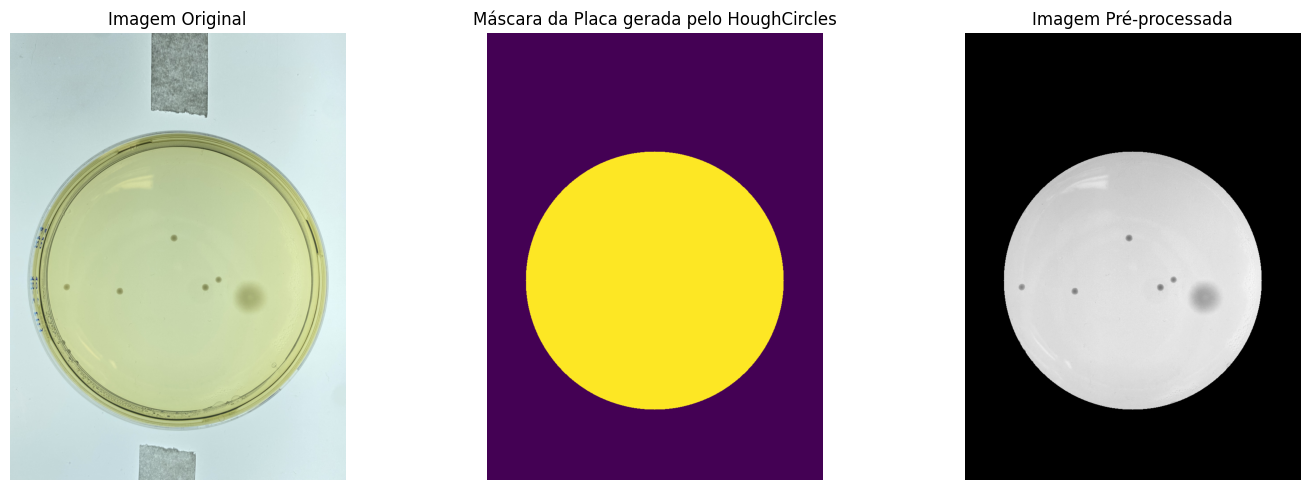

In [25]:
import os
import matplotlib.pyplot as plt
original_image = cv2.imread(os.path.join(IMAGES_DIR, "IMG_0636.jpg"))
pre_processed_image, mask = preprocess(os.path.join(IMAGES_DIR, "IMG_0636.jpg"))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask)
plt.title("Máscara da Placa gerada pelo HoughCircles")
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(pre_processed_image, cmap='gray')
plt.title("Imagem Pré-processada")
plt.axis('off')

plt.tight_layout()


## 4. Processamento em lote e salvamento das imagens pré-processadas

Após validar o pipeline em uma imagem de exemplo, aplicamos o mesmo
pré-processamento em todas as imagens `.jpg` da pasta `data/raw`.

Para cada arquivo:

1. a imagem é carregada e processada pela função `preprocess`;
2. o nome original é preservado;
3. o resultado é salvo em `data/interim`.

Esse passo gera o conjunto de entrada padronizado que será utilizado no
notebook de contagem automática de colônias.


## 5. Verificação dos arquivos gerados

A célula seguinte lista os arquivos de entrada encontrados e executa o
salvamento das imagens pré-processadas.

Ao final da execução, a pasta `data/interim` deve conter uma versão
pré-processada para cada imagem original em `data/raw`, preservando os nomes
de arquivo para facilitar o rastreamento entre entrada e saída.


In [26]:
import glob
caminho_busca = os.path.join(IMAGES_DIR, "*.jpg")
imagens_encontradas = glob.glob(caminho_busca)

print(f"Foram encontradas {len(imagens_encontradas)} imagens na pasta {IMAGES_DIR}.")

for caminho_completo in imagens_encontradas:
    pre_processed_image, mask = preprocess(caminho_completo)
    nome_arquivo = os.path.basename(caminho_completo)
    nome_saida = os.path.join(CROP_CIRCLES_DIR, f"{nome_arquivo}")
    cv2.imwrite(nome_saida, pre_processed_image)


print(f"{len(imagens_encontradas)} imagens foram pré-processadas e salvas em '{CROP_CIRCLES_DIR}'.")

Foram encontradas 94 imagens na pasta /Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks/../data/raw.
94 imagens foram pré-processadas e salvas em '/Users/leonardorafaelpires/Personal/unicamp/pattern-recognition-2026/IA901-2026S1/projetos/pattern-recognition-in-petri-dishes/notebooks/../data/interim'.
